# Round 003 — ตระกูล C: สัญญาณราคา และ พื้นฐาน × ราคา

**ทำอะไร:** ทดสอบ momentum, ความผันผวนต่ำ, trend, ใกล้จุดสูงสุด 52 สัปดาห์ และการผสมกับคุณภาพ/มูลค่า rebalance รายเดือน

**อุปมา:** ดู "แรงส่ง" ของหุ้น (ราคาที่กำลังวิ่ง) ร่วมกับ "สุขภาพ" (งบการเงิน) — เหมือนเลือกนักวิ่งที่ทั้งฟิตและกำลังฟอร์มดี

**อ่านผลอย่างไร:** เหมือน round ก่อน — สเปกใน rounds/round_003/HYPOTHESIS.md

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_003/results.csv")
cols = [c for c in ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"] if c in r.columns]
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 200)
display(r[cols].round(3))
ok = lambda c: r[c].astype(str).str.lower().eq("true")
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[ok("S1") & ok("S2") & ok("S3") & ok("S6")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r003_C_MOM_overall,0.626,0.614,0.681,0.116,0.122,-0.359,-0.384,False,False,0.189,0.016,64.507,51,0.922,1.093
1,r003_C_MOM_sector,0.627,0.614,0.681,0.115,0.122,-0.370,-0.384,False,False,0.108,0.012,64.507,51,1.049,1.093
2,r003_C_LOWVOL_overall,0.677,0.614,0.681,0.105,0.122,-0.319,-0.384,False,False,0.297,0.007,64.535,51,1.633,1.093
3,r003_C_LOWVOL_sector,0.605,0.614,0.681,0.103,0.122,-0.347,-0.384,False,False,0.135,0.003,64.535,51,1.451,1.093
4,r003_C_TREND_overall,0.701,0.614,0.681,0.130,0.122,-0.347,-0.384,False,False,0.595,0.040,64.535,51,1.052,1.093
5,r003_C_TREND_sector,0.701,0.614,0.681,0.128,0.122,-0.346,-0.384,False,False,0.541,0.035,64.535,51,1.124,1.093
6,r003_C_HI52_overall,0.667,0.614,0.681,0.109,0.122,-0.304,-0.384,False,False,0.432,0.008,64.535,51,1.282,1.093
7,r003_C_HI52_sector,0.609,0.614,0.681,0.103,0.122,-0.321,-0.384,False,False,0.135,0.003,64.535,51,1.256,1.093
8,r003_C_QMOM_overall,0.793,0.614,0.681,0.148,0.122,-0.328,-0.384,False,False,0.892,0.119,64.340,51,0.905,1.093
9,r003_C_QMOM_sector,0.631,0.614,0.681,0.114,0.122,-0.346,-0.384,False,False,0.216,0.010,64.340,51,1.045,1.093


ผู้เข้ารอบ (S1+S2+S3+S6): []


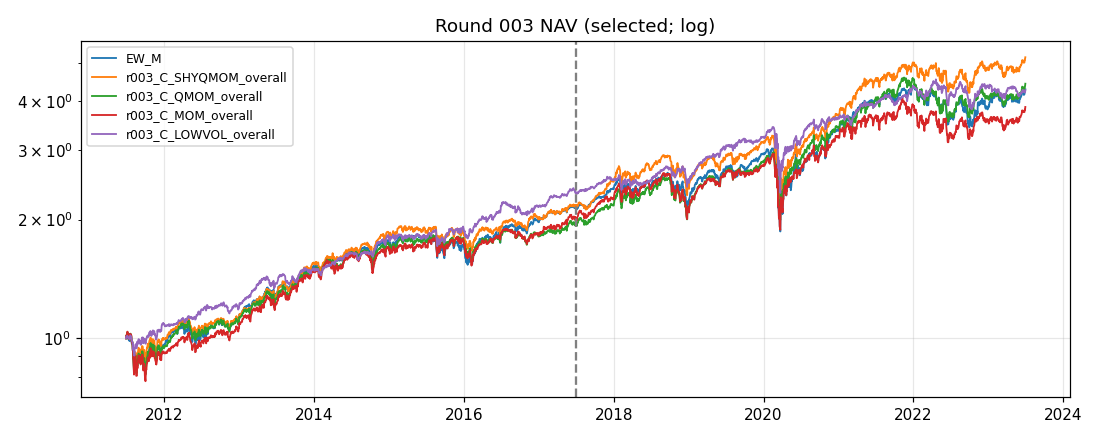

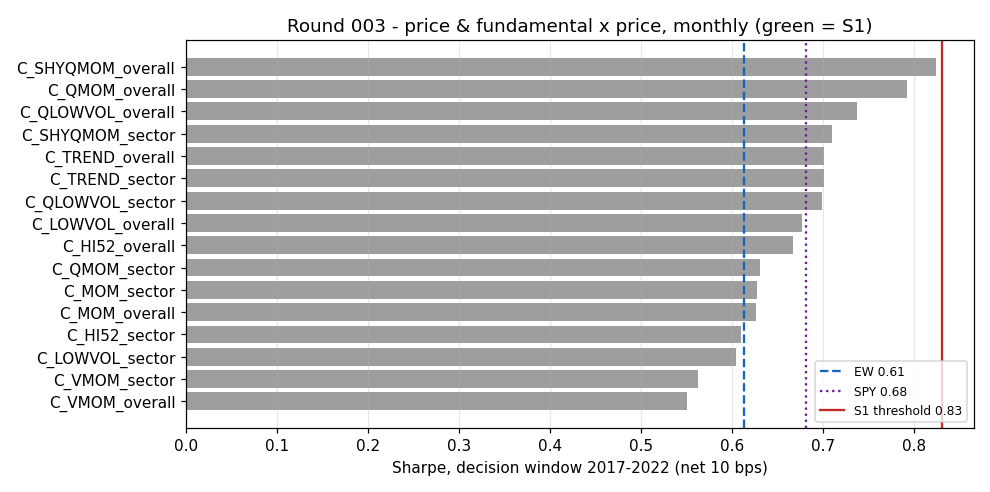

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_003_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_003/RESULTS.md").read_text()))

# Round 003 — ผล (ตระกูล C: สัญญาณราคา และ พื้นฐาน × ราคา, rebalance รายเดือน) — **ไม่มีผู้เข้ารอบ**

- trial รอบนี้ 16 → สะสม **73**; ตาราง `results.csv`; กราฟ `figures/round_003_*.png`
- benchmark ช่วงตัดสิน: EW(U) รายเดือน Sharpe 0.614 · SPY 0.681 → S1 ต้อง ≥ 0.831
- ⚠️ รันครั้งแรกมีบั๊กปฏิทิน (momentum หาย 6 เดือน) — แก้แล้วรันใหม่ด้วยสเปกเดิม (ดู `autorun/DEVIATIONS.md`; ผลก่อนแก้ `run_buggy.log`)

| ผลสำคัญ | ตัวเลข |
|---|---|
| ผ่าน S1 | **ไม่มี** |
| ใกล้ที่สุด | `C_SHYQMOM_overall` (shareholder yield + quality + momentum): Sharpe 0.824, CAGR 15.6% vs EW 12.2%, S2 100%, DSR 0.301; ช่วงประกอบ 1.182 vs EW 1.093 |
| `C_QMOM_overall` | 0.793 (S2 89%) แต่ช่วงประกอบแพ้ EW (0.905 vs 1.093) |
| momentum เดี่ยว | 0.626–0.627 ≈ EW |
| low volatility | ช่วงตัดสิน 0.605–0.677 แต่ช่วงประกอบ 1.451–1.633 (ดีมาก) — ไม่เสถียรข้ามช่วง |
| value + momentum | 0.550–0.563 — แพ้ EW |
| walk-forward | corr(ส่วนเกินช่วงประกอบ, ช่วงตัดสิน) = 0.144; ตัวที่ดีที่สุดช่วงประกอบ `C_LOWVOL_overall` (+0.541) ได้ +0.064 ในช่วงตัดสิน |

## การตีความ
- สัญญาณราคาเดี่ยวไม่ได้เด่นในหุ้นใหญ่ช่วงนี้ (ต่างจากผลของ Gu-Kelly-Xiu ที่รวมหุ้นเล็กและช่วงยาวกว่า)
- คู่ "shareholder yield + quality" ยังเป็นแกนที่สม่ำเสมอที่สุด (round 002 และ 003) — แต่ทุกรูปแบบยังต่ำกว่าเกณฑ์ S1 เล็กน้อยและ DSR ต่ำ
- การเลือกตัวที่ "เกือบผ่าน" ไปปรับต่อคือความเสี่ยง overfit — round 004 จะทำเฉพาะตามที่ประกาศล่วงหน้าและนับ trial ทุกตัว
